In [1]:
# 03.09.2026 - 20260903c.ipynb: KTORY CZYNNIK KATALOGU PRODUKUJE FALSZYWE
# MINIMA - LICZBA ZDARZEN CZY SKLAD MAGNITUD.
#
# JEDEN watek (konwencja repo: jeden watek = jeden notebook).
#
# PUNKT WYJSCIA. 20260903b pokazal, ze katalog o plaskim tempie daje 0,14
# minimum na realizacje, a nie 39/50 minimow przy 1968, jak zapisal dziennik
# 02.09. Kontrola wykazala, ze statystyka jest ta sama (korelacja 0,999976 z
# krzywa z 26.08), wiec roznica siedzi w GENERATORZE katalogu. Lektura kodu
# 20260902c pokazala, na czym polega roznica: tamtejsza funkcja zbuduj_katalog()
# losowala magnitudy z rozkladu TEGO SAMEGO ROKU dla kazdego profilu tempa,
# takze dla profilu "tempo_plaskie". Plaskie bylo wiec tylko TEMPO (liczba
# zdarzen na rok), a nie sklad magnitud.
#
# To ma znaczenie, bo statystyka z sekcji 4 nie liczy zdarzen - liczy SUME
# MAGNITUD w koszu (Sm):
#       Sm(rok) ~ n(rok) * srednia_magnituda(rok)
# Profil plaski zerowal pierwszy czynnik i zostawial drugi. Jesli sklad
# magnitud w katalogu USGS dryfuje przez dekady, to "plaski" katalog z 02.09
# nadal mial wieloletni trend w wielkosci, ktora metoda faktycznie mierzy.
#
# TO JEST NA RAZIE WNIOSEK Z LEKTURY KODU, NIE POMIAR. Ten notebook zamienia go
# w pomiar.
#
# PYTANIE: czy sam dryf skladu magnitud, przy DOKLADNIE stalym tempie trzesien,
# wystarcza do wyprodukowania glebokich minimow - czy potrzebna jest do tego
# rowniez zmiana liczby zdarzen.
#
# PLAN 2x2. Dwa czynniki, kazdy w dwoch stanach, wszystkie cztery kombinacje:
#
#                        | magnitudy z TEGO SAMEGO ROKU | magnitudy z CALOSCI
#   ---------------------+------------------------------+---------------------
#   tempo PRAWDZIWE      | tempo_praw__mag_rok          | tempo_praw__mag_glob
#   tempo PLASKIE        | tempo_plaskie__mag_rok       | tempo_plaskie__mag_glob
#
# Dwie komorki tej tabeli sa juz znane z 20260903b i sluza jako KONTROLA
# przepisania generatora:
#   tempo_praw__mag_rok         odpowiada tamtejszemu "surogat z trendem" (4,96
#                               minimum na realizacje),
#   tempo_plaskie__mag_glob     odpowiada tamtejszemu "surogat plaski" (0,14).
# Trzecia komorka, tempo_plaskie__mag_rok, to jest de facto profil
# "tempo_plaskie" z 20260902c - czyli ta, ktora rzekomo dawala 39/50 przy 1968.
# Czwarta domyka plan i mowi, ile daje sama liczba zdarzen bez trendu magnitud.
#
# CO WE WSZYSTKICH CZTERECH WERSJACH JEST IDENTYCZNE (zeby nie mieszac zmiennych):
#  - laczna liczba zdarzen, co do jednego, rowna liczbie zdarzen w prawdziwym
#    katalogu (metoda najwiekszych reszt przy zamianie tempa na liczby calkowite),
#  - czasy losowane jednostajnie w obrebie roku, czyli caly rozklad wewnatrz
#    roku (grupowanie wstrzasow wtornych, sezonowosc) zniszczony z konstrukcji,
#  - poprawka na niepelny rok 2025 (katalog konczy sie 31 stycznia),
#  - ta sama statystyka, ta sama siatka t0, ten sam prog detekcji minimow.
#
# REGULY ODCZYTU - USTALONE PRZED ZOBACZENIEM WYNIKU.
# Wielkoscia rozstrzygajaca jest LICZBA MINIMOW NA REALIZACJE dla wersji
# tempo_plaskie__mag_rok, porownana z dwiema znanymi komorkami (0,14 i 4,96):
#   A - SAM SKLAD MAGNITUD WYSTARCZA, jesli tempo_plaskie__mag_rok daje >= 2,0
#       minimum na realizacje. Wtedy nasza teza obowiazuje w wersji mocnej:
#       minima powstaja z wieloletniego dryfu skladu magnitud nawet przy
#       calkowicie stalym tempie trzesien, a rozbieznosc z 02.09 jest wyjasniona
#       i ZMIERZONA.
#   B - SKLAD MAGNITUD NIE WYSTARCZA, jesli tempo_plaskie__mag_rok daje <= 0,5.
#       Wtedy minima wymagaja zmiany LICZBY zdarzen, teza obowiazuje tylko w
#       wersji slabszej, a rozbieznosc z 02.09 ma inna przyczyne, ktorej nadal
#       nie znamy - i trzeba to wprost zapisac w dzienniku.
#   C - OBA CZYNNIKI DZIALAJA, jesli wynik miesci sie miedzy 0,5 a 2,0.
#       Raportowac jako taki, bez wybierania jednej z dwoch narracji.
# Osobno, niezaleznie od A/B/C: jesli tempo_plaskie__mag_rok kladzie wiekszosc
# swoich minimow w latach 1965-1970, odtwarza to wprost obserwacje z 02.09
# ("23 z 44 minimow w latach 1965-1968") i przyczyna jest wskazana wprost.
#
# KONTROLA NADRZEDNA, bez ktorej wynikow nie wolno czytac: dwie znane komorki
# planu musza sie odtworzyc co do rzedu wielkosci - tempo_praw__mag_rok w
# okolicy 5 minimow na realizacje, tempo_plaskie__mag_glob ponizej 0,5. Jesli
# nie, generator zostal przepisany blednie i caly notebook jest niewazny.
# (Nie wymagam zgodnosci co do cyfry, bo ziarna sa inne, a wersja plaska w
# 20260903b losowala czasy jednostajnie po CALYM zakresie, tu zas - jednostajnie
# w obrebie roku przy rownej liczbie zdarzen na rok. To ten sam proces z
# dokladnoscia do dyskretyzacji rocznej.)
#
# CZEGO TEN NOTEBOOK NIE ROZSTRZYGA: nie mowi, czy artykul ma racje. Mowi
# wylacznie, ktora wlasnosc KATALOGU wystarcza, zeby metoda z sekcji 4
# wyprodukowala minimum tam, gdzie zadnego zwiazku CR-EQ nie ma.
#
# KOSZT [szacunek]: 201 krzywych (1 prawdziwa + 4 wersje x 50 realizacji) po
# 74 322 punkty t0. W 20260903b 100 krzywych surogatowych poszlo w 5,7 min na
# 20 rdzeniach (3,4 s na krzywa), wiec tu okolo 11-12 min.
import json
import os
import sys
import time

import numpy as np
import pandas as pd
from scipy.signal import find_peaks
from scipy.stats import binom

sys.path.insert(0, "..")
from mc_parallel import run_jobs_parallel

RESULTS_DIR = "../results"
DATA_DIR = "../data"
USGS_PATH = f"{DATA_DIR}/usgs_data/usgs_m4_1965_2025.csv"
MOSC_PATH = f"{DATA_DIR}/mosc_data.csv"

P_DAYS, D_DAYS, M_THRESHOLD, DT_DAYS = 3350, 5, 4.0, 15
PROG_WYSOKOSCI = 5.0
STACJA = "mosc"          # ta sama co 20260902b/c i 20260903b
N_KRZYWYCH = 50          # realizacji kazdej z czterech wersji
ZIARNO_BAZOWE = 20260903

WERSJE = ["tempo_praw__mag_rok", "tempo_praw__mag_glob",
          "tempo_plaskie__mag_rok", "tempo_plaskie__mag_glob"]

katalog = pd.read_csv(USGS_PATH, usecols=["time", "mag"])
katalog["time"] = pd.to_datetime(katalog["time"], utc=True).dt.tz_localize(None)
katalog = katalog[katalog["mag"] >= M_THRESHOLD].sort_values("time").reset_index(drop=True)

cr = pd.read_csv(MOSC_PATH)
cr["datetime"] = pd.to_datetime(cr["datetime"])
cr = cr.set_index("datetime").sort_index()["value"]

print(f"Katalog USGS M>={M_THRESHOLD}: {len(katalog)} zdarzen, "
      f"{katalog['time'].min().date()} .. {katalog['time'].max().date()}")
print(f"CR {STACJA}: {len(cr)} pomiarow, {cr.index.min().date()} .. {cr.index.max().date()}")

Katalog USGS M>=4.0: 507919 zdarzen, 1965-01-01 .. 2025-01-31
CR mosc: 91824 pomiarow, 1960-01-01 .. 2025-03-23


In [2]:
# STATYSTYKA. Przepisana bez zmian z 20260903b (a tam z 20260902a/b, a tam z
# przepisu referencyjnego 20260826d). Zadnych modyfikacji - notebook ma
# porownywac generatory, wiec statystyka musi byc dokladnie ta sama.
_STEP_NS = np.int64(D_DAYS * 86400 * 10 ** 9)
_LAG_NS = np.int64(DT_DAYS * 86400 * 10 ** 9)
_N_KOSZY = int(P_DAYS // D_DAYS)
_OFFSETY = _STEP_NS * np.arange(_N_KOSZY + 1, dtype=np.int64)


def przygotuj_szereg(s):
    t = s.index.values.astype("datetime64[ns]").astype(np.int64)
    v = s.to_numpy(dtype=float)
    ok = ~np.isnan(v)
    return t, np.append(np.where(ok, v, 0.0), 0.0), np.append(ok.astype(np.int64), 0)


def przygotuj_katalog(kat):
    return przygotuj_szereg(kat.set_index("time")["mag"].sort_index())


def _sumy_koszy(wartosci, idx):
    s = np.add.reduceat(wartosci, idx)[:-1]
    s[idx[1:] == idx[:-1]] = 0
    return s


def _znaki(cr_prep, eq_prep, t0_ns):
    krawedzie = t0_ns + _OFFSETY
    ct, cv, cn = cr_prep
    ci = np.searchsorted(ct, krawedzie, side="left")
    suma, liczba = _sumy_koszy(cv, ci), _sumy_koszy(cn, ci)
    with np.errstate(invalid="ignore", divide="ignore"):
        cr_vals = np.where(liczba > 0, suma / np.maximum(liczba, 1), np.nan)
    et, ev, _ = eq_prep
    ei = np.searchsorted(et, krawedzie + _LAG_NS, side="left")
    sm_vals = _sumy_koszy(ev, ei)
    nCR_i, nCR_im1 = cr_vals[1:], cr_vals[:-1]
    dCR, Sm = nCR_i - nCR_im1, sm_vals[1:]
    A = Sm / np.nanmedian(Sm) - 1
    B = np.abs(dCR) / np.nanmedian(np.abs(dCR)) - 1
    valid = ((A != 0) & (B != 0) & (nCR_i > 0) & (nCR_im1 > 0) & (Sm > 0)
             & ~np.isnan(A) & ~np.isnan(B))
    c = (A * B)[valid]
    return int((c > 0).sum()), int(valid.sum())


def y_krzywa(cr_prep, eq_prep, siatka_ns):
    Np = np.zeros(len(siatka_ns), dtype=np.int64)
    Nv = np.zeros(len(siatka_ns), dtype=np.int64)
    for i, t0_ns in enumerate(siatka_ns):
        Np[i], Nv[i] = _znaki(cr_prep, eq_prep, t0_ns)
    y = np.full(len(siatka_ns), np.nan)
    ok = Nv > 0
    y[ok] = -np.log10(binom.pmf(Np[ok], Nv[ok], 0.5))
    return y

In [3]:
# SIATKA t0 I KONTROLA. Siatka wprost z finetune_*.csv z 26.08, tak samo jak
# 20260902a/b/c i 20260903b. Kontrola: nasza krzywa musi odtworzyc tamta.
ft = (pd.read_csv(f"{RESULTS_DIR}/finetune_{STACJA}_P3350_d5_dt15_fullhistory.csv",
                  parse_dates=["t0"]).sort_values("t0").reset_index(drop=True))
siatka = ft["t0"]
siatka_ns = siatka.values.astype("datetime64[ns]").astype(np.int64)
cr_prep = przygotuj_szereg(cr)
KROK_DNI = (siatka.iloc[1] - siatka.iloc[0]) / pd.Timedelta(days=1)
DISTANCE = int(round(P_DAYS / KROK_DNI))
print(f"Siatka t0: {len(siatka)} punktow, krok {KROK_DNI * 24:.0f} h, "
      f"{siatka.iloc[0].date()} .. {siatka.iloc[-1].date()}")
print(f"find_peaks: prog {PROG_WYSOKOSCI}, distance {DISTANCE} probek (= {P_DAYS} dni)")

y_prawdziwa = y_krzywa(cr_prep, przygotuj_katalog(katalog), siatka_ns)
_d = np.abs(y_prawdziwa - (-np.log10(ft["PPDF"].to_numpy())))
_ok = ~np.isnan(_d)
print(f"\nKontrola wzgledem krzywej z 26.08: korelacja "
      f"{np.corrcoef(y_prawdziwa[_ok], -np.log10(ft['PPDF'].to_numpy())[_ok])[0, 1]:.6f}, "
      f"mediana |roznicy| {np.nanmedian(_d):.5f}, "
      f"punktow z |roznica| > 0,2: {int(np.nansum(_d > 0.2))} / {len(_d)}")

# Ery katalogu prawdziwego - do naniesienia na wykresy jako punkt odniesienia.
_piki_praw, _ = find_peaks(np.nan_to_num(y_prawdziwa, nan=-1.0),
                           height=PROG_WYSOKOSCI, distance=DISTANCE)
daty_praw = [siatka.iloc[p] for p in _piki_praw]
print("\nEry katalogu prawdziwego: "
      + ", ".join(f"{d.date()} ({y_prawdziwa[p]:.2f})"
                  for d, p in zip(daty_praw, _piki_praw)))

Siatka t0: 74322 punktow, krok 6 h, 1965-01-01 .. 2015-11-15
find_peaks: prog 5.0, distance 13400 probek (= 3350 dni)

Kontrola wzgledem krzywej z 26.08: korelacja 0.999976, mediana |roznicy| 0.00000, punktow z |roznica| > 0,2: 0 / 74322

Ery katalogu prawdziwego: 1968-07-12 (9.72), 1978-05-24 (5.83), 1988-08-30 (6.79), 1999-03-10 (7.67), 2008-09-27 (8.79)


In [4]:
# GENERATOR 2x2. Jedna funkcja, dwa przelaczniki - zeby bylo widac czarno na
# bialym, ze wersje roznia sie WYLACZNIE tymi dwoma rzeczami.
#
# tempo:     "praw"    - liczby zdarzen na rok dokladnie jak w katalogu,
#            "plaskie" - te same laczne zdarzenia rozlozone rowno na lata
#                        (proporcjonalnie do pokrycia roku).
# magnitudy: "rok"     - losowane ze zwracaniem z puli TEGO SAMEGO roku,
#            "glob"    - losowane ze zwracaniem z puli calego katalogu.
#
# Rok 2025 jest niepelny (do 31 stycznia), wiec tempo plaskie liczymy jako
# stala liczbe zdarzen na PELNY rok, przemnozona przez faktyczne pokrycie -
# inaczej "plaski" katalog mialby na koncu sztuczny pik gestosci.
_KAT_OD, _KAT_DO = katalog["time"].min(), katalog["time"].max()
_grupy = {int(r): g["mag"].to_numpy() for r, g in katalog.groupby(katalog["time"].dt.year)}
LATA = np.array(sorted(_grupy))
LICZBY = np.array([len(_grupy[int(r)]) for r in LATA], dtype=float)
GRANICE = {}
for r in LATA:
    od = max(pd.Timestamp(year=int(r), month=1, day=1), _KAT_OD)
    do = min(pd.Timestamp(year=int(r) + 1, month=1, day=1), _KAT_DO)
    GRANICE[int(r)] = (od, (do - od).total_seconds())
DLUGOSC_ROKU = np.array([(pd.Timestamp(year=int(r) + 1, month=1, day=1)
                          - pd.Timestamp(year=int(r), month=1, day=1)).total_seconds()
                         for r in LATA])
POKRYCIE = np.array([GRANICE[int(r)][1] for r in LATA]) / DLUGOSC_ROKU
_WSZYSTKIE_MAG = katalog["mag"].to_numpy()


def do_liczb(tempo_profilu):
    """Profil tempa (zdarzen na PELNY rok) -> calkowite liczby zdarzen na rok,
    o sumie DOKLADNIE rownej liczbie zdarzen w prawdziwym katalogu. Metoda
    najwiekszych reszt, ta sama co w 20260902c."""
    surowe = np.asarray(tempo_profilu, dtype=float) * POKRYCIE
    surowe = surowe / surowe.sum() * LICZBY.sum()
    dol = np.floor(surowe).astype(int)
    brak = int(round(LICZBY.sum() - dol.sum()))
    if brak > 0:
        dol[np.argsort(-(surowe - dol))[:brak]] += 1
    return dol


TEMPO_PRAW = LICZBY / POKRYCIE
LICZBY_WERSJI = {
    "praw": do_liczb(TEMPO_PRAW),
    "plaskie": do_liczb(np.full(len(LATA), TEMPO_PRAW.mean())),
}


def zbuduj(wersja, ziarno):
    tempo, magi = wersja.split("__")
    liczby = LICZBY_WERSJI[tempo.replace("tempo_", "")]
    rng = np.random.default_rng(ziarno)
    czesci = []
    for i, rok in enumerate(LATA):
        n = int(liczby[i])
        if n == 0:
            continue
        poczatek, dlugosc = GRANICE[int(rok)]
        pula = _grupy[int(rok)] if magi == "mag_rok" else _WSZYSTKIE_MAG
        czesci.append(pd.DataFrame(dict(
            time=poczatek + pd.to_timedelta(rng.uniform(0, dlugosc, n), unit="s"),
            mag=rng.choice(pula, size=n, replace=True))))
    s = pd.concat(czesci, ignore_index=True).sort_values("time").reset_index(drop=True)
    s["time"] = s["time"].dt.floor("s").astype("datetime64[us]")
    return s


# KONTROLA GENERATORA. Kluczowa kolumna to NIE liczba zdarzen, tylko SUMA
# MAGNITUD w dekadzie - bo to jest wielkosc, ktora statystyka faktycznie czyta.
def _dekady(kat):
    a = kat[(kat["time"] >= "1970") & (kat["time"] < "1980")]
    b = kat[(kat["time"] >= "2005") & (kat["time"] < "2015")]
    return len(a), len(b), a["mag"].sum(), b["mag"].sum(), a["mag"].mean(), b["mag"].mean()


print(f"{'wersja':24s} {'zdarzen':>8s} {'n 05-14/70-79':>14s} "
      f"{'Sm 05-14/70-79':>15s} {'sr.mag 70-79':>13s} {'sr.mag 05-14':>13s}")
_probki = {}
for w in ["prawdziwy"] + WERSJE:
    kat = katalog if w == "prawdziwy" else zbuduj(w, ZIARNO_BAZOWE)
    _probki[w] = kat
    n1, n2, s1, s2, m1, m2 = _dekady(kat)
    print(f"{w:24s} {len(kat):8d} {n2 / n1:14.2f} {s2 / s1:15.2f} "
          f"{m1:13.4f} {m2:13.4f}")
print()
print("Odczyt: kolumna 'n' mowi, czy splaszczylismy TEMPO; kolumna 'Sm' mowi,")
print("czy splaszczylismy to, co statystyka naprawde czyta. Roznica miedzy nimi")
print("w wierszu tempo_plaskie__mag_rok jest cala trescia tego notebooka.")

wersja                    zdarzen  n 05-14/70-79  Sm 05-14/70-79  sr.mag 70-79  sr.mag 05-14
prawdziwy                  507919           4.36            4.05        4.9037        4.5495
tempo_praw__mag_rok        507919           4.36            4.05        4.9031        4.5488
tempo_praw__mag_glob       507919           4.36            4.36        4.6032        4.6004
tempo_plaskie__mag_rok     507919           1.00            0.90        5.0607        4.5581
tempo_plaskie__mag_glob    507919           1.00            1.00        4.6002        4.5990

Odczyt: kolumna 'n' mowi, czy splaszczylismy TEMPO; kolumna 'Sm' mowi,
czy splaszczylismy to, co statystyka naprawde czyta. Roznica miedzy nimi
w wierszu tempo_plaskie__mag_rok jest cala trescia tego notebooka.


Zapisano ../results/czynniki_1_suma_magnitud.png


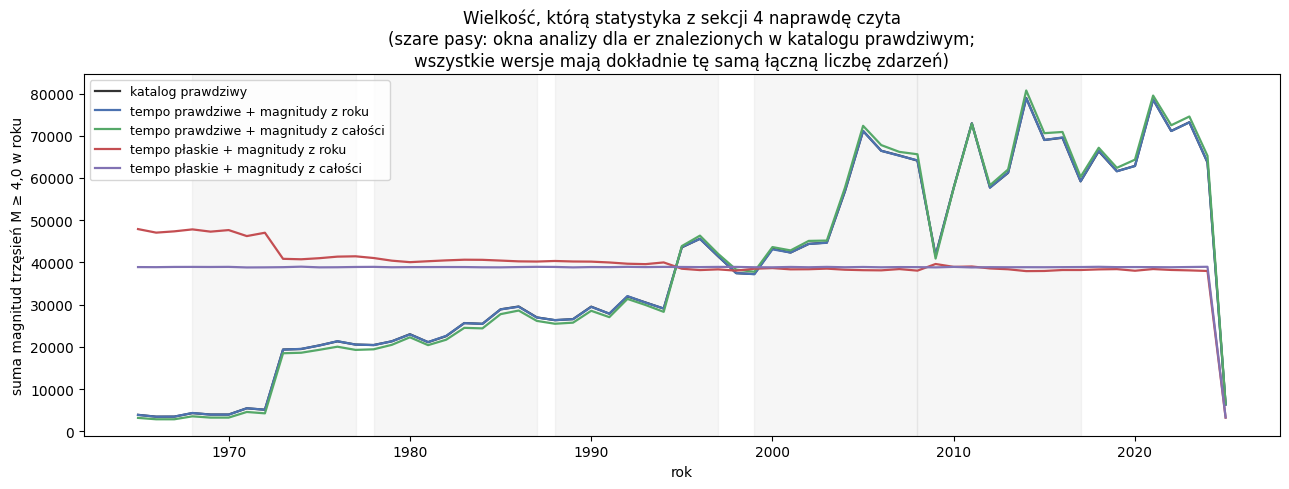

In [5]:
# WYKRES 1 (jedno kodowanie: wysokosc krzywej) - SUMA MAGNITUD NA ROK w kazdej
# z czterech wersji plus katalog prawdziwy. To jest wielkosc, ktora statystyka
# czyta, i to na niej widac, czym rozni sie "plaski" od "plaskiego".
import matplotlib.pyplot as plt

KOLORY = {"prawdziwy": "#333333", "tempo_praw__mag_rok": "#4C72B0",
          "tempo_praw__mag_glob": "#55A868", "tempo_plaskie__mag_rok": "#C44E52",
          "tempo_plaskie__mag_glob": "#8172B3"}
ETYKIETY = {"prawdziwy": "katalog prawdziwy",
            "tempo_praw__mag_rok": "tempo prawdziwe + magnitudy z roku",
            "tempo_praw__mag_glob": "tempo prawdziwe + magnitudy z całości",
            "tempo_plaskie__mag_rok": "tempo płaskie + magnitudy z roku",
            "tempo_plaskie__mag_glob": "tempo płaskie + magnitudy z całości"}

fig, ax = plt.subplots(figsize=(13, 5))
for w in ["prawdziwy"] + WERSJE:
    kat = _probki[w]
    s = kat.groupby(kat["time"].dt.year)["mag"].sum()
    ax.plot(s.index, s.to_numpy(), color=KOLORY[w], lw=1.6, label=ETYKIETY[w])
for d in daty_praw:
    ax.axvspan(d.year, (d + pd.Timedelta(days=P_DAYS)).year, color="gray", alpha=0.07)
ax.set_xlabel("rok")
ax.set_ylabel("suma magnitud trzęsień M ≥ 4,0 w roku")
ax.set_title("Wielkość, którą statystyka z sekcji 4 naprawdę czyta\n"
             "(szare pasy: okna analizy dla er znalezionych w katalogu prawdziwym;\n"
             "wszystkie wersje mają dokładnie tę samą łączną liczbę zdarzeń)")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/czynniki_1_suma_magnitud.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/czynniki_1_suma_magnitud.png")

In [6]:
# SKAN. 201 krzywych: 1 prawdziwa + 4 wersje x N_KRZYWYCH realizacji. Detekcja
# minimow idzie od razu w zadaniu, wiec na dysk trafia mala tabela zamiast
# dwustu krzywych po 74 tysiace punktow.
SCIEZKA_MINIMA = f"{RESULTS_DIR}/czynniki_minima_{STACJA}.csv"
SCIEZKA_KONFIG = f"{RESULTS_DIR}/czynniki_config_{STACJA}.json"
PRZELICZ_OD_NOWA = False


def konfiguracja():
    return dict(STACJA=STACJA, P_DAYS=P_DAYS, D_DAYS=D_DAYS, DT_DAYS=DT_DAYS,
                M_THRESHOLD=M_THRESHOLD, PROG_WYSOKOSCI=PROG_WYSOKOSCI,
                DISTANCE=DISTANCE, N_KRZYWYCH=N_KRZYWYCH, ZIARNO_BAZOWE=ZIARNO_BAZOWE,
                WERSJE=WERSJE, katalog_n=int(len(katalog)), n_siatka=int(len(siatka)))


def zadanie(job):
    typ, ziarno = job
    y = y_prawdziwa if typ == "prawdziwy" else y_krzywa(
        cr_prep, przygotuj_katalog(zbuduj(typ, ziarno)), siatka_ns)
    piki, _ = find_peaks(np.nan_to_num(y, nan=-1.0), height=PROG_WYSOKOSCI,
                         distance=DISTANCE)
    return dict(typ=typ, ziarno=int(ziarno), n_minimow=int(len(piki)),
                max_krzywej=float(np.nanmax(y)),
                minima_t0=";".join(str(siatka.iloc[p]) for p in piki),
                minima_wys=";".join(f"{y[p]:.4f}" for p in piki))


zadania = [("prawdziwy", 0)]
for i, w in enumerate(WERSJE):
    zadania += [(w, ZIARNO_BAZOWE + 1000 * i + j) for j in range(N_KRZYWYCH)]

wczytano = False
if not PRZELICZ_OD_NOWA and os.path.exists(SCIEZKA_MINIMA) and os.path.exists(SCIEZKA_KONFIG):
    if json.load(open(SCIEZKA_KONFIG)) == json.loads(json.dumps(konfiguracja())):
        surowe = pd.read_csv(SCIEZKA_MINIMA, keep_default_na=False)
        wczytano = len(surowe) == len(zadania)
        print(f"WCZYTANO gotowe wyniki z {SCIEZKA_MINIMA} - nic nie liczono."
              if wczytano else "Zapisany plik nie ma tylu wierszy - liczymy od nowa.")
    else:
        print("Zapisana konfiguracja nie pasuje do biezacej - liczymy od nowa.")

if not wczytano:
    print(f"Liczymy {len(zadania)} krzywych x {len(siatka)} punktow t0.")
    start = time.time()
    surowe = run_jobs_parallel(zadanie, zadania, opis="krzywych", raport_co=10)
    print(f"Czas calkowity: {(time.time() - start) / 60:.1f} min")
    surowe.to_csv(SCIEZKA_MINIMA, index=False)
    json.dump(konfiguracja(), open(SCIEZKA_KONFIG, "w"), indent=1)
    print(f"Zapisano {SCIEZKA_MINIMA}")

print(f"\nWierszy: {len(surowe)}; " + ", ".join(
    f"{k} x{v}" for k, v in surowe["typ"].value_counts().items()))

Liczymy 201 krzywych x 74322 punktow t0.
  10/201 krzywych; minelo 1.4 min, zostalo ~25.8 min
  20/201 krzywych; minelo 1.4 min, zostalo ~12.7 min
  30/201 krzywych; minelo 2.7 min, zostalo ~15.2 min
  40/201 krzywych; minelo 2.8 min, zostalo ~11.2 min
  50/201 krzywych; minelo 4.0 min, zostalo ~12.1 min
  60/201 krzywych; minelo 4.1 min, zostalo ~9.7 min
  70/201 krzywych; minelo 5.4 min, zostalo ~10.1 min
  80/201 krzywych; minelo 5.5 min, zostalo ~8.4 min
  90/201 krzywych; minelo 6.8 min, zostalo ~8.4 min
  100/201 krzywych; minelo 6.9 min, zostalo ~7.0 min
  110/201 krzywych; minelo 7.8 min, zostalo ~6.4 min
  120/201 krzywych; minelo 7.9 min, zostalo ~5.3 min
  130/201 krzywych; minelo 8.8 min, zostalo ~4.8 min
  140/201 krzywych; minelo 8.9 min, zostalo ~3.9 min
  150/201 krzywych; minelo 9.8 min, zostalo ~3.3 min
  160/201 krzywych; minelo 10.0 min, zostalo ~2.6 min
  170/201 krzywych; minelo 10.8 min, zostalo ~2.0 min
  180/201 krzywych; minelo 11.0 min, zostalo ~1.3 min
  190

In [7]:
# LICZBY ROZSTRZYGAJACE. Tabela 2x2 w tej samej postaci, w jakiej byla
# postawiona hipoteza: ile minimow na realizacje daje kazda kombinacja.
n_praw = int(surowe.loc[surowe.typ == "prawdziwy", "n_minimow"].iloc[0])
print(f"Katalog prawdziwy: {n_praw} minimow (odniesienie).\n")

wyniki = {w: surowe.loc[surowe.typ == w, "n_minimow"].to_numpy() for w in WERSJE}
print(f"{'wersja':26s} {'minimow/realizacje':>19s} {'realizacji z >=1':>17s} "
      f"{'max krzywej (mediana)':>22s}")
for w in WERSJE:
    v = wyniki[w]
    mx = surowe.loc[surowe.typ == w, "max_krzywej"].median()
    print(f"{w:26s} {v.mean():19.2f} {int((v >= 1).sum()):14d}/{len(v)} {mx:22.2f}")

print()
print("TA SAMA TABELA W UKLADZIE 2x2 (minimow na realizacje):")
print(f"{'':18s} {'mag z roku':>12s} {'mag z calosci':>15s}")
for tempo, etyk in [("tempo_praw", "tempo prawdziwe"), ("tempo_plaskie", "tempo plaskie")]:
    a = wyniki[f"{tempo}__mag_rok"].mean()
    b = wyniki[f"{tempo}__mag_glob"].mean()
    print(f"{etyk:18s} {a:12.2f} {b:15.2f}")

print()
print("KONTROLA NADRZEDNA (dwie komorki znane z 20260903b):")
_k1 = wyniki["tempo_praw__mag_rok"].mean()
_k2 = wyniki["tempo_plaskie__mag_glob"].mean()
print(f"  tempo_praw__mag_rok      = {_k1:.2f}  (20260903b: 4,96 dla 'z trendem')"
      f"  -> {'OK' if _k1 >= 3.0 else 'NIEZGODNE'}")
print(f"  tempo_plaskie__mag_glob  = {_k2:.2f}  (20260903b: 0,14 dla 'plaskiego')"
      f"  -> {'OK' if _k2 <= 0.5 else 'NIEZGODNE'}")
KONTROLA_OK = bool(_k1 >= 3.0 and _k2 <= 0.5)

Katalog prawdziwy: 5 minimow (odniesienie).

wersja                      minimow/realizacje  realizacji z >=1  max krzywej (mediana)
tempo_praw__mag_rok                       4.90             50/50                  11.88
tempo_praw__mag_glob                      4.88             50/50                  11.47
tempo_plaskie__mag_rok                    0.80             37/50                   5.57
tempo_plaskie__mag_glob                   0.08              4/50                   3.98

TA SAMA TABELA W UKLADZIE 2x2 (minimow na realizacje):
                     mag z roku   mag z calosci
tempo prawdziwe            4.90            4.88
tempo plaskie              0.80            0.08

KONTROLA NADRZEDNA (dwie komorki znane z 20260903b):
  tempo_praw__mag_rok      = 4.90  (20260903b: 4,96 dla 'z trendem')  -> OK
  tempo_plaskie__mag_glob  = 0.08  (20260903b: 0,14 dla 'plaskiego')  -> OK


In [8]:
# GDZIE LEZA MINIMA. Osobne pytanie od "ile ich jest": dziennik 02.09 mowil nie
# tylko o liczbie, ale o SKUPIENIU minimow w latach 1965-1968.
wiersze = []
for r in surowe.itertuples():
    if not r.minima_t0:
        continue
    for d, h in zip(r.minima_t0.split(";"), r.minima_wys.split(";")):
        wiersze.append(dict(typ=r.typ, ziarno=r.ziarno, t0=pd.Timestamp(d),
                            wysokosc=float(h)))
minima = pd.DataFrame(wiersze)
print(f"Minimow lacznie: {len(minima)}\n")

print("ROZKLAD MINIMOW PO PIECIOLECIACH (kolumny: wersja)")
kraw = list(range(1965, 2020, 5))
naglowek = f"{'okres':>12s}" + "".join(f"{w.replace('tempo_', '').replace('mag_', ''):>22s}"
                                       for w in WERSJE)
print(naglowek)
for lo in kraw:
    linia = f"{f'{lo}-{lo + 4}':>12s}"
    for w in WERSJE:
        g = minima[(minima.typ == w) & (minima.t0.dt.year >= lo)
                   & (minima.t0.dt.year < lo + 5)]
        linia += f"{len(g):>22d}"
    print(linia)
print(f"{'RAZEM':>12s}" + "".join(f"{int((minima.typ == w).sum()):>22d}" for w in WERSJE))

print()
print("UDZIAL MINIMOW W LATACH 1965-1970 (obserwacja z 02.09: 23 z 44):")
for w in WERSJE:
    g = minima[minima.typ == w]
    wczesne = int((g.t0.dt.year < 1970).sum())
    print(f"  {w:26s} {wczesne:4d} / {len(g):4d}"
          + (f"  = {wczesne / len(g):.0%}" if len(g) else "  = -"))

Minimow lacznie: 538

ROZKLAD MINIMOW PO PIECIOLECIACH (kolumny: wersja)
       okres             praw__rok            praw__glob          plaskie__rok         plaskie__glob
   1965-1969                    50                    50                    35                     1
   1970-1974                     0                     0                     0                     1
   1975-1979                    50                    50                     0                     0
   1980-1984                     0                     0                     0                     0
   1985-1989                    50                    49                     3                     0
   1990-1994                     0                     1                     1                     0
   1995-1999                    50                    49                     0                     0
   2000-2004                     0                     1                     1                     1
   2005-2009      

Zapisano ../results/czynniki_2_liczba_minimow.png


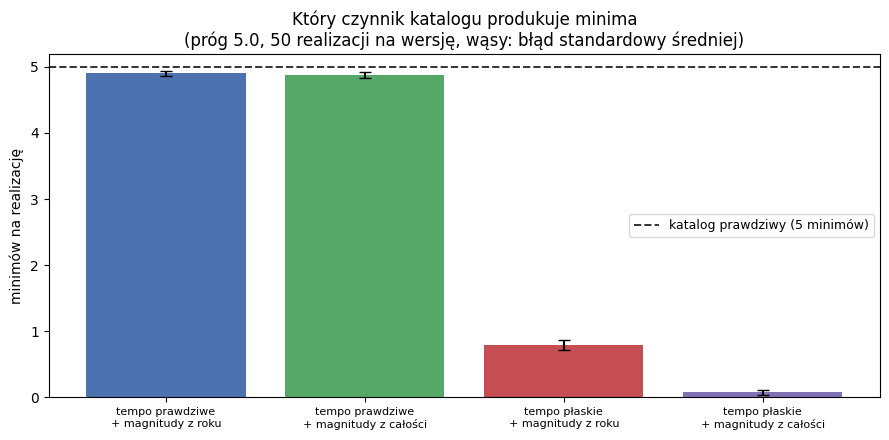

In [9]:
# WYKRES 2 (jedno kodowanie: wysokosc slupka) - ile minimow daje kazda z
# czterech kombinacji, na tle katalogu prawdziwego.
fig, ax = plt.subplots(figsize=(9, 4.5))
sr = [wyniki[w].mean() for w in WERSJE]
bledy = [wyniki[w].std(ddof=1) / np.sqrt(len(wyniki[w])) for w in WERSJE]
ax.bar(range(len(WERSJE)), sr, yerr=bledy, capsize=4,
       color=[KOLORY[w] for w in WERSJE])
ax.axhline(n_praw, color="#333333", ls="--", lw=1.4,
           label=f"katalog prawdziwy ({n_praw} minimów)")
ax.set_xticks(range(len(WERSJE)))
ax.set_xticklabels([ETYKIETY[w].replace(" + ", "\n+ ") for w in WERSJE], fontsize=8)
ax.set_ylabel("minimów na realizację")
ax.set_title("Który czynnik katalogu produkuje minima\n"
             f"(próg {PROG_WYSOKOSCI}, {N_KRZYWYCH} realizacji na wersję, "
             "wąsy: błąd standardowy średniej)")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/czynniki_2_liczba_minimow.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/czynniki_2_liczba_minimow.png")

Zapisano ../results/czynniki_3_polozenie_minimow.png


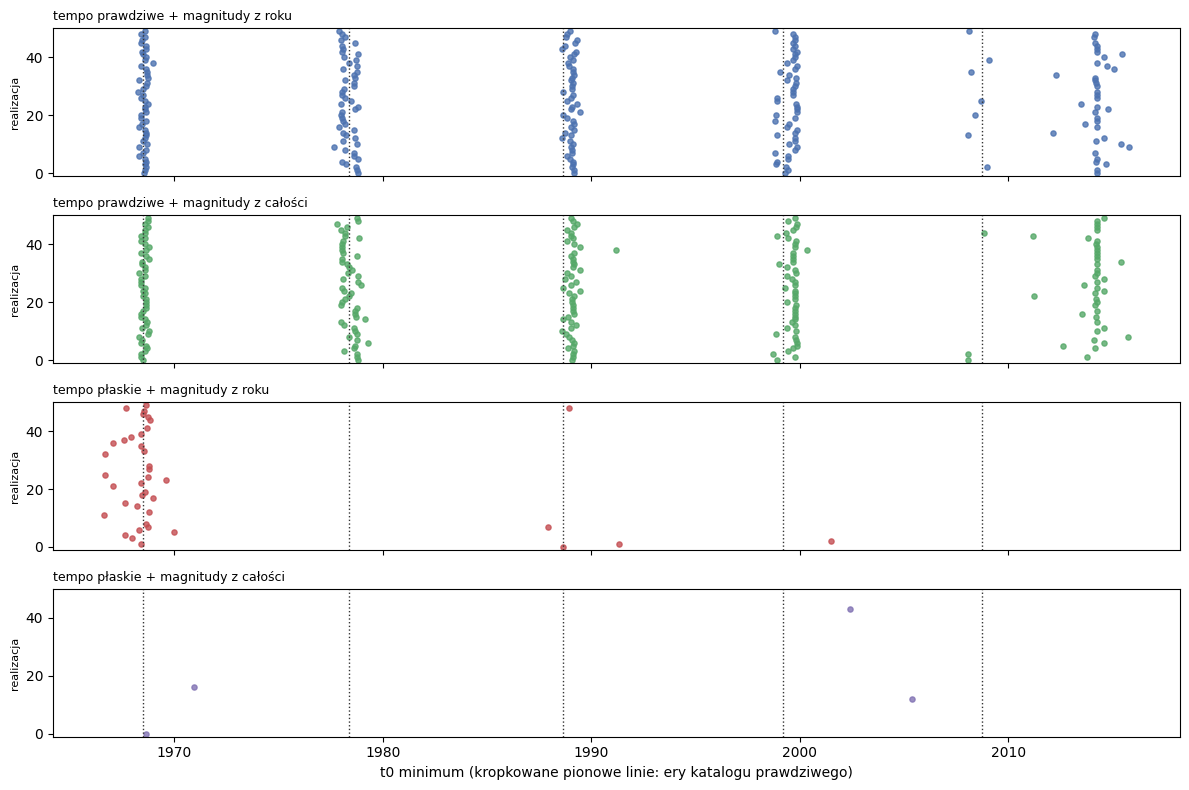

In [10]:
# WYKRES 3 (jedno kodowanie: polozenie znacznika na osi czasu) - gdzie leza
# minima kazdej wersji. Jeden panel na wersje, jeden wiersz na realizacje.
fig, osie = plt.subplots(len(WERSJE), 1, figsize=(12, 2.0 * len(WERSJE)), sharex=True)
for ax, w in zip(np.atleast_1d(osie), WERSJE):
    g = minima[minima.typ == w]
    ziarna = sorted(surowe.loc[surowe.typ == w, "ziarno"].unique())
    poz = {z: i for i, z in enumerate(ziarna)}
    if len(g):
        ax.scatter(g["t0"], [poz[z] for z in g["ziarno"]], s=14,
                   color=KOLORY[w], alpha=0.8)
    for d in daty_praw:
        ax.axvline(d, color="#333333", ls=":", lw=1.0)
    ax.set_ylim(-1, len(ziarna))
    ax.set_ylabel("realizacja", fontsize=8)
    ax.set_title(ETYKIETY[w], fontsize=9, loc="left")
np.atleast_1d(osie)[-1].set_xlabel("t0 minimum (kropkowane pionowe linie: ery katalogu prawdziwego)")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/czynniki_3_polozenie_minimow.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/czynniki_3_polozenie_minimow.png")

In [11]:
# PODSUMOWANIE, czytane wedlug regul ustalonych w komorce 0 PRZED liczeniem.
kluczowa = wyniki["tempo_plaskie__mag_rok"].mean()
print("=" * 78)
print("KTORY CZYNNIK PRODUKUJE FALSZYWE MINIMA - PODSUMOWANIE")
print("=" * 78)
print()
if not KONTROLA_OK:
    print("KONTROLA NADRZEDNA NIE PRZESZLA - dwie znane komorki planu 2x2 nie")
    print("odtworzyly wynikow z 20260903b. Generator zostal przepisany blednie,")
    print("ponizszego odczytu NIE WOLNO uzywac. Sprawdzic funkcje zbuduj().")
    print()
print(f"tempo_plaskie__mag_rok daje {kluczowa:.2f} minimum na realizacje")
print(f"  (dla porownania: tempo plaskie + magnitudy globalne "
      f"{wyniki['tempo_plaskie__mag_glob'].mean():.2f}, "
      f"tempo prawdziwe + magnitudy z roku {wyniki['tempo_praw__mag_rok'].mean():.2f})")
print()
if kluczowa >= 2.0:
    print("ODCZYT A: SAM SKLAD MAGNITUD WYSTARCZA. Przy DOKLADNIE stalym tempie")
    print("trzesien wieloletni dryf skladu magnitud produkuje glebokie minima.")
    print("KONSEKWENCJE:")
    print(" 1. Rozbieznosc miedzy 20260902c a 20260903b jest WYJASNIONA I")
    print("    ZMIERZONA - profil 'tempo_plaskie' z 02.09 nie byl kontrola.")
    print(" 2. Nasza teza obowiazuje w wersji mocnej: minima metody z sekcji 4")
    print("    powstaja z wieloletniego trendu SUMY MAGNITUD w katalogu USGS,")
    print("    obojetne czy pochodzi on z liczby zdarzen, czy z ich skladu.")
    print(" 3. Kazda kontrola surogatowa w tym repo musi odtad splaszczac SUME")
    print("    MAGNITUD, a nie liczbe zdarzen. Dotyczy to takze 20260902c.")
elif kluczowa <= 0.5:
    print("ODCZYT B: SAM SKLAD MAGNITUD NIE WYSTARCZA. Do wyprodukowania minimow")
    print("potrzebna jest zmiana LICZBY zdarzen, a nie tylko ich skladu.")
    print("KONSEKWENCJE:")
    print(" 1. Wyjasnienie rozbieznosci z 02.09 podane w dzienniku 03.09 jest")
    print("    BLEDNE i trzeba je wycofac - przyczyna lezy gdzie indziej.")
    print(" 2. Nastepny krok: porownac wprost krzywe z 20260902c i 20260903b na")
    print("    tym samym ziarnie, zamiast wnioskowac z generatorow.")
    print(" 3. Teza o trendzie sumy magnitud obowiazuje tylko w wersji slabszej:")
    print("    napedza ja liczba zdarzen, sklad magnitud jest drugorzedny.")
else:
    print("ODCZYT C: OBA CZYNNIKI DZIALAJA. Sklad magnitud sam z siebie podnosi")
    print("liczbe minimow ponad poziom katalogu bez zadnego trendu, ale nie")
    print("dochodzi do poziomu katalogu z prawdziwym tempem. Raportowac jako")
    print("taki, bez wybierania jednej z dwoch narracji.")
print()
_g = minima[minima.typ == "tempo_plaskie__mag_rok"]
if len(_g):
    _w = int((_g.t0.dt.year < 1970).sum())
    print(f"SKUPIENIE PRZY 1968: {_w} z {len(_g)} minimow tej wersji "
          f"({_w / len(_g):.0%}) lezy przed 1970.")
    print("Dziennik 02.09 raportowal dla swojego profilu plaskiego 23 z 44 (52%).")
    if _w / len(_g) >= 0.4:
        print("ODTWARZA obserwacje z 02.09 - przyczyna wskazana wprost.")
    else:
        print("NIE odtwarza skupienia z 02.09 - sama liczba minimow to za malo,")
        print("ich rozklad w czasie jest inny i wymaga osobnego wyjasnienia.")
else:
    print("SKUPIENIE PRZY 1968: ta wersja nie dala zadnych minimow.")
print()
print("OGRANICZENIE: jedna stacja (" + STACJA.upper() + "), jeden katalog, jeden")
print("prog detekcji. Powtorzenie na hrms to zmiana stalej STACJA w komorce 0.")

KTORY CZYNNIK PRODUKUJE FALSZYWE MINIMA - PODSUMOWANIE

tempo_plaskie__mag_rok daje 0.80 minimum na realizacje
  (dla porownania: tempo plaskie + magnitudy globalne 0.08, tempo prawdziwe + magnitudy z roku 4.90)

ODCZYT C: OBA CZYNNIKI DZIALAJA. Sklad magnitud sam z siebie podnosi
liczbe minimow ponad poziom katalogu bez zadnego trendu, ale nie
dochodzi do poziomu katalogu z prawdziwym tempem. Raportowac jako
taki, bez wybierania jednej z dwoch narracji.

SKUPIENIE PRZY 1968: 35 z 40 minimow tej wersji (88%) lezy przed 1970.
Dziennik 02.09 raportowal dla swojego profilu plaskiego 23 z 44 (52%).
ODTWARZA obserwacje z 02.09 - przyczyna wskazana wprost.

OGRANICZENIE: jedna stacja (MOSC), jeden katalog, jeden
prog detekcji. Powtorzenie na hrms to zmiana stalej STACJA w komorce 0.
